# Plano de Execução do Projeto

Neste projeto, será realizada uma análise completa de um experimento A/B conduzido em uma loja virtual internacional, com o objetivo de avaliar o impacto da implementação de um novo sistema de recomendações.

O trabalho seguirá as etapas descritas abaixo:

1. Inicialmente, será feita a preparação e limpeza dos dados, incluindo verificação de consistência, tratamento de valores ausentes e remoção de duplicatas. Também será garantido que apenas usuários elegíveis para o experimento sejam considerados, respeitando os critérios de período e região estabelecidos no teste.

2. Em seguida, será realizada a validação do teste, verificando possíveis contaminações entre grupos e garantindo a correta distribuição dos participantes.

3. Após a análise exploratória, serão realizados testes estatísticos apropriados para avaliar a significância das diferenças observadas entre os grupos. Serão aplicados testes de comparação de proporções para a taxa de conversão e testes não paramétricos para métricas contínuas, como ticket médio e receita por usuário.

4. Por fim, serão aplicados testes estatísticos adequados para verificar a significância das diferenças observadas, e será apresentada uma conclusão consolidada com uma decisão fundamentada sobre a continuidade ou encerramento do teste.

# 1. Inicialização

In [1]:
# Carregar todas as bibliotecas
import numpy as np
from scipy import stats as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

# 2. Carregando Dados

## 2.1. Preparação de Dados

In [2]:
# Carregar os arquivos de dados em diferentes DataFrames
data_marketing_events = pd.read_csv('ab_project_marketing_events_us.csv', parse_dates=['start_dt','finish_dt'])
data_new_users = pd.read_csv('final_ab_new_users_upd_us.csv', parse_dates=['first_date'])
data_events = pd.read_csv('final_ab_events_upd_us.csv', parse_dates=['event_dt'])
data_participants = pd.read_csv('final_ab_participants_upd_us.csv')
#pd.set_option('display.max_rows', None)  # Exibe todas as linhas

## 2.2. Tratamento de Dados

### 2.2.1. Verificando duplicatas

In [3]:
# Verificando duplicatas
print(data_marketing_events.duplicated().sum())

print(data_new_users.duplicated().sum())

print(data_participants.duplicated().sum())

print(data_events.duplicated().sum())

0
0
0
0


### 2.2.2.`data_marketing_events`

In [4]:
data_marketing_events.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   name       14 non-null     object        
 1   regions    14 non-null     object        
 2   start_dt   14 non-null     datetime64[ns]
 3   finish_dt  14 non-null     datetime64[ns]
dtypes: datetime64[ns](2), object(2)
memory usage: 2.4 KB


*Sem valores ausentes.*

In [5]:
data_marketing_events.head()

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


*O experimento é exclusivo para União Europeia, portanto, os eventos de outras localidades serão excluídos.*

In [6]:
# Filtrando apenas usuários da União Europeia
data_marketing_events = data_marketing_events[data_marketing_events['regions'].str.contains('EU')].reset_index(drop=True)

In [7]:
data_marketing_events

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,Black Friday Ads Campaign,"EU, CIS, APAC, N.America",2020-11-26,2020-12-01
5,Labor day (May 1st) Ads Campaign,"EU, CIS, APAC",2020-05-01,2020-05-03
6,International Women's Day Promo,"EU, CIS, APAC",2020-03-08,2020-03-10


### 2.2.3. `data_new_users`

In [8]:
data_new_users.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     58703 non-null  object        
 1   first_date  58703 non-null  datetime64[ns]
 2   region      58703 non-null  object        
 3   device      58703 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 11.4 MB


*Sem valores ausentes.*

In [9]:
data_new_users.head()

,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


*O experimento é exclusivo para União Europeia, portanto, usuários de outras regiões serão desconsiderados.*

In [10]:
# Filtrando apenas usuários da União Europeia
data_new_users = data_new_users[data_new_users['region'] == 'EU'].reset_index(drop=True)

In [11]:
data_new_users.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43396 entries, 0 to 43395
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     43396 non-null  object        
 1   first_date  43396 non-null  datetime64[ns]
 2   region      43396 non-null  object        
 3   device      43396 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 8.4 MB


### 2.2.4. `data_participants`

In [12]:
data_participants.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
dtypes: object(3)
memory usage: 2.9 MB


*Sem valores ausentes.*

In [13]:
data_participants.head()

,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


In [14]:
# verificando coluna ab_test
data_participants['ab_test'].unique()

array(['recommender_system_test', 'interface_eu_test'], dtype=object)

In [15]:
# Mantendo apenas usuários do teste recommender_system_test
data_participants = data_participants[data_participants['ab_test'] == 'recommender_system_test'].reset_index(drop=True)

In [16]:
data_participants.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3675 entries, 0 to 3674
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  3675 non-null   object
 1   group    3675 non-null   object
 2   ab_test  3675 non-null   object
dtypes: object(3)
memory usage: 757.4 KB


In [17]:
# checando a existência de usuários em mais de um grupo
# quantos grupos cada usuário aparece
user_groups = data_participants.groupby('user_id')['group'].nunique()

# usuários que estão em mais de um grupo
multi_group_users = user_groups[user_groups > 1].index

print('Total de usuários em mais de um grupo:', multi_group_users.shape[0])

Total de usuários em mais de um grupo: 0


### 2.2.5. `data_events`

In [18]:
data_events.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     423761 non-null  object        
 1   event_dt    423761 non-null  datetime64[ns]
 2   event_name  423761 non-null  object        
 3   details     60314 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 62.4 MB


*Possui valores ausentes pois `details` só é preenchido para eventos "**purchase**", para "**login**","**product_page**" e "**product_cart**", o valor não existe.*

In [19]:
data_events.head()

,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99


### 2.2.6. Usuários Válidos

In [20]:
# Mantendo apenas usuários presentes nas duas tabelas
# Fazendo uma interseção entre 'new_users' e 'participants', selecionando apenas usuários que existam nos dois dataframes ao mesmo tempo
valid_users = set(data_new_users['user_id']).intersection(set(data_participants['user_id']))

In [21]:
data_new_users = data_new_users[data_new_users['user_id'].isin(valid_users)].reset_index(drop=True)

In [22]:
data_participants = data_participants[data_participants['user_id'].isin(valid_users)].reset_index(drop=True)

In [23]:
data_events = data_events[data_events['user_id'].isin(valid_users)].reset_index(drop=True)

In [24]:
data_events.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22674 entries, 0 to 22673
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     22674 non-null  object        
 1   event_dt    22674 non-null  datetime64[ns]
 2   event_name  22674 non-null  object        
 3   details     3079 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 3.3 MB


*Usuários sem correspondência completa entre as tabelas foram removidos para evitar vieses e garantir consistência na análise do funil.*

---

In [25]:
# verificando data de ínicio e final do teste
# Calculando ínicio e fim do teste
max_date = data_events['event_dt'].max()
min_date = data_events['event_dt'].min()
print('Data de início do teste:', min_date)
print('Data final do teste:', max_date)

Data de início do teste: 2020-12-07 00:05:57
Data final do teste: 2020-12-30 12:42:57


*As datas de início e término dos eventos estão coerentes com o período do experimento. Para atender às condições do teste, foram considerados apenas eventos ocorridos até 14 dias após a data de inscrição de cada usuário.*

In [26]:
# juntando eventos com data de inscrição
data_events = data_events.merge(data_new_users[['user_id', 'first_date']], on='user_id', how='left')
# garantindo tipo datetime
data_events['event_dt'] = pd.to_datetime(data_events['event_dt'])
data_events['first_date'] = pd.to_datetime(data_events['first_date'])
# diferença entre evento e inscrição
data_events['days_since_signup'] = (data_events['event_dt'] - data_events['first_date']).dt.days
# mantendo apenas eventos válidos
data_events = data_events[data_events['days_since_signup'] <= 14].reset_index(drop=True)

In [27]:
# contando quantos grupos distintos cada usuário tem
user_groups = (
    data_participants
    .groupby('user_id')['group']
    .nunique()
    .reset_index()
)
# usuários que aparecem em mais de um grupo
contaminated_users = user_groups[user_groups['group'] > 1]

print('Número de usuários contaminados:', contaminated_users.shape[0])

Número de usuários contaminados: 0


*A análise não identificou usuários presentes em mais de um grupo do experimento*

In [28]:
# adicionando a coluna 'group' de 'data_participants' a 'data_new_users'
# selecionando apenas user_id e group da tabela de participantes
participants_groups = data_participants[['user_id', 'group']]
# adicionando a coluna 'group' à tabela de novos usuários
data_new_users = data_new_users.merge(
    participants_groups,
    on='user_id',
    how='left'  # mantém todos os usuários de data_new_users
)
data_new_users.head(1)

,user_id,first_date,region,device,group
0,D72A72121175D8BE,2020-12-07,EU,PC,A


In [29]:
# adicionando a coluna 'group' de 'data_participants' a 'data_events'
# adicionando a coluna 'group' à tabela de novos usuários
data_events = data_events.merge(
    participants_groups,
    on='user_id',
    how='left'  # mantém todos os usuários de data_new_users
)
data_events.head(1)

,user_id,event_dt,event_name,details,first_date,days_since_signup,group
0,831887FE7F2D6CBA,2020-12-07 06:50:29,purchase,4.99,2020-12-07,0,A


## 2.3. Estatísticas Descritivas

In [30]:
data_events.describe()

,details,days_since_signup
count,3018.000000,22157.000000
mean,22.670583,2.816672
std,69.131201,3.431593
min,4.990000,0.000000
25%,4.990000,0.000000
50%,4.990000,1.000000
75%,9.990000,4.000000
max,499.990000,14.000000


In [31]:
# Contando o total de usuários únicos
total_users = data_events['user_id'].nunique()
print('Total de usuários únicos:', total_users ,'usuários.')


Total de usuários únicos: 3481 usuários.


In [32]:
# Total de eventos dividido por usuários únicos
mean_events_users = round( data_events['event_name'].count()/ total_users, 2)
print('Número médio de eventos por usuário:', mean_events_users)

Número médio de eventos por usuário: 6.37


---
*A análise descritiva confirma que os dados estão alinhados ao desenho do experimento. As datas de inscrição e de eventos respeitam os limites definidos, e todos os eventos analisados ocorreram dentro da janela de até 14 dias após o cadastro do usuário. Além disso, os valores de compra são consistentes com um cenário real de e-commerce, e os valores ausentes na coluna details estão corretamente associados a eventos não transacionais.*

*É possivel observar uma média provavelmente muito maior que a mediana. Isso já sugere presença de outliers.*

## 2.4. Funil de conversão

In [33]:
# contar usuários únicos por etapa e grupo
funnel = (
    data_events[data_events['event_name'].isin(['product_page','product_cart','purchase'])]
    .groupby(['group','event_name'])['user_id']
    .nunique()
    .reset_index()
)

funnel

,group,event_name,user_id
0,A,product_cart,782
1,A,product_page,1685
2,A,purchase,833
3,B,product_cart,244
4,B,product_page,493
5,B,purchase,249


In [34]:
#transormar em formato de funil
funnel_pivot = funnel.pivot(index='event_name', columns='group', values='user_id')

funnel_pivot = funnel_pivot.loc[
    ['product_page','product_cart','purchase']
]

funnel_pivot

group,A,B
event_name,,
product_page,1685,493
product_cart,782,244
purchase,833,249


In [35]:
# Calcular conversão entre etapas
conversion_funnel = funnel_pivot.copy()

conversion_funnel.loc['product_cart'] = (
    funnel_pivot.loc['product_cart'] /
    funnel_pivot.loc['product_page']
)

conversion_funnel.loc['purchase'] = (
    funnel_pivot.loc['purchase'] /
    funnel_pivot.loc['product_cart']
)

conversion_funnel.loc['product_page'] = 1

conversion_funnel

group,A,B
event_name,,
product_page,1.000000,1.000000
product_cart,0.464095,0.494929
purchase,1.065217,1.020492


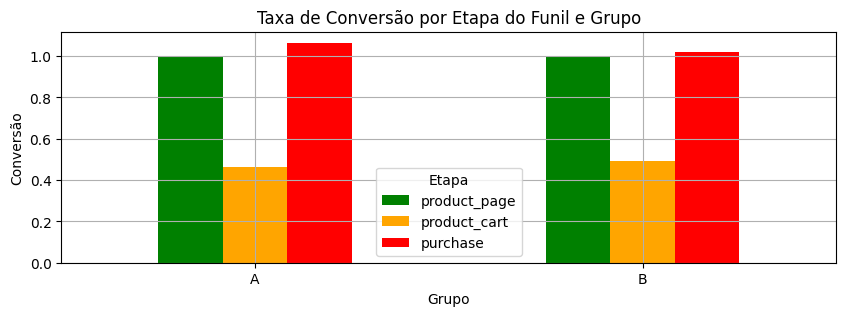

In [36]:
#gráfico de conversão por etapa
conversion_funnel.T.plot(
    kind='bar',
    figsize=(10,3),
    color = ('green', 'orange', 'red')
)

plt.title('Taxa de Conversão por Etapa do Funil e Grupo')
plt.ylabel('Conversão')
plt.xlabel('Grupo')
plt.xticks(rotation=0)
plt.legend(title='Etapa')
plt.grid()
plt.show()

* **Etapa `product_page - product_cart`:**

  * Aproximadamente **46,4% dos usuários do grupo A** adicionaram produtos ao carrinho após visualizar a página do produto.
  * No **grupo B**, essa proporção é **49,5%**.

* **Etapa `product_cart - purchase`:**

  * As taxas observadas são **superiores a 1 (106,5% no grupo A e 102,0% no grupo B)**.
  * Em um funil de conversão tradicional, **valores acima de 100% não são possíveis**, pois o número de usuários que completam uma etapa não deveria ser maior que o número de usuários da etapa anterior.

> Esse resultado sugere que **existem usuários que realizaram uma compra sem possuir registro do evento `product_cart`**. Isso pode ocorrer por diferentes motivos, como acessos diretos à finalização da compra, registros incompletos de eventos intermediários ou limitações no rastreamento do comportamento do usuário.

>> Apesar da **inconsistência** observada na última etapa do funil, é possível notar que ambos os grupos apresentam comportamento semelhante nas etapas iniciais do processo de compra, com uma leve vantagem do Grupo B na transição da visualização do produto para o carrinho.

In [37]:
# número de eventos por dia e por tipo de evento
events_per_day = (
    data_events
    .groupby([data_events['event_dt'].dt.date, 'event_name'])
    .size()
    .reset_index(name='count')
)

# reorganizar dados para formato adequado ao gráfico
events_per_day = events_per_day.pivot(
    index='event_dt',
    columns='event_name',
    values='count'
)
events_per_day.head()

event_name,login,product_cart,product_page,purchase
event_dt,,,,
2020-12-07,303,76,193,102
2020-12-08,259,67,159,66
2020-12-09,332,89,202,86
2020-12-10,280,77,155,68
2020-12-11,260,60,141,56


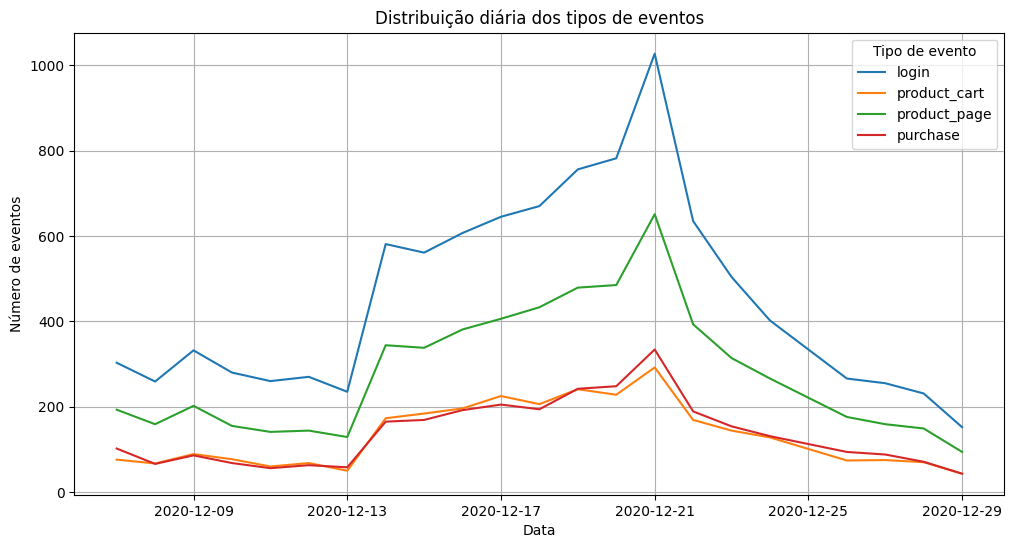

In [38]:
# gráfico
plt.figure(figsize=(12,6))

for column in events_per_day.columns:
    plt.plot(events_per_day.index, events_per_day[column], label=column)

plt.title('Distribuição diária dos tipos de eventos')
plt.xlabel('Data')
plt.ylabel('Número de eventos')
plt.xticks(rotation=0)
plt.grid()
plt.legend(title='Tipo de evento')

plt.show()

* **No Início do período (07 a 13 de dezembro)** o volume de eventos é relativamente **baixo e estável**.
  * Isso sugere um **nível moderado de atividade dos usuários** no início do experimento.

* **Há um crescimento do volume de eventos (14 a 21 de dezembro)**, onde observa-se um **aumento significativo em todos os tipos de eventos**.
  * Esse período representa o **pico de interação na plataforma durante o experimento**.

* **Pico de atividade (21 de dezembro)**. Nesse dia apresenta-se o maior volume de eventos em todas as categorias.
  * Isso pode indicar um momento de **maior tráfego ou interesse dos usuários**, possivelmente associado a fatores externos como campanhas ou proximidade da data festiva *Christmas&New Year Promo*.

* **Queda gradual após o pico (22 a 29 de dezembro)**
  * Isso sugere uma **diminuição natural da atividade dos usuários ao final do período analisado**.

* **Inconsistências no funil de eventos**

    * Em alguns dias, como **21 de dezembro**, o número de `purchases` é maior que o de `product_cart`, o que não seria esperado em um funil tradicional.

    * Isso sugere que nem todas as compras passam necessariamente pelo evento `product_cart`.

**Conclusão**

> O gráfico mostra que a atividade dos usuários aumenta significativamente na metade do período do experimento, atingindo um pico em 21 de dezembro, seguido por uma queda gradual. Apesar de o volume de eventos seguir tendências semelhantes entre os tipos de interação, a sequência de eventos não forma um funil perfeitamente hierárquico, indicando possíveis lacunas no registro de eventos ou caminhos alternativos no processo de compra.

# 3. Análise de Teste A/B

## 3.1. Receita Acumulada

In [39]:
#Calcular a receita acumulada ao longo do tempo, separada por grupo A e B

# filtrando apenas eventos de compra
purchases = data_events[data_events['event_name'] == 'purchase'].copy()

# adicionando a informação de grupo aos eventos de compra
purchases = purchases.merge(
    data_participants['user_id'],
    on='user_id',
    how='inner'  # mantém apenas usuários que participam do teste
)

In [40]:
purchases.head(3)

,user_id,event_dt,event_name,details,first_date,days_since_signup,group
0,831887FE7F2D6CBA,2020-12-07 06:50:29,purchase,4.99,2020-12-07,0,A
1,831887FE7F2D6CBA,2020-12-09 02:19:17,purchase,99.99,2020-12-07,2,A
2,3C5DD0288AC4FE23,2020-12-07 19:42:40,purchase,4.99,2020-12-07,0,A


In [41]:
# criando coluna apenas com a data (sem hora)
purchases['event_date'] = purchases['event_dt'].dt.date

# receita diária por grupo
daily_revenue = (
    purchases
    .groupby(['group', 'event_date'])['details']
    .sum()
    .reset_index()
    .rename(columns={'details': 'daily_revenue'})
)
daily_revenue.head()

,group,event_date,daily_revenue
0,A,2020-12-07,1104.57
1,A,2020-12-08,754.67
2,A,2020-12-09,759.53
3,A,2020-12-10,809.58
4,A,2020-12-11,1089.60


In [42]:
# ordenando por grupo e data
daily_revenue = daily_revenue.sort_values(by=['group', 'event_date'])

# calculando a receita acumulada por grupo
daily_revenue['cumulative_revenue'] = (
    daily_revenue
    .groupby('group')['daily_revenue']
    .cumsum()
)
daily_revenue.head()

,group,event_date,daily_revenue,cumulative_revenue
0,A,2020-12-07,1104.57,1104.57
1,A,2020-12-08,754.67,1859.24
2,A,2020-12-09,759.53,2618.77
3,A,2020-12-10,809.58,3428.35
4,A,2020-12-11,1089.60,4517.95


In [43]:
#armazenando os dados relativos a datas e receita para os grupos A e B
cumulativeRevenueA = daily_revenue[daily_revenue['group']=='A'][['event_date','cumulative_revenue']]
cumulativeRevenueB = daily_revenue[daily_revenue['group']=='B'][['event_date','cumulative_revenue']]

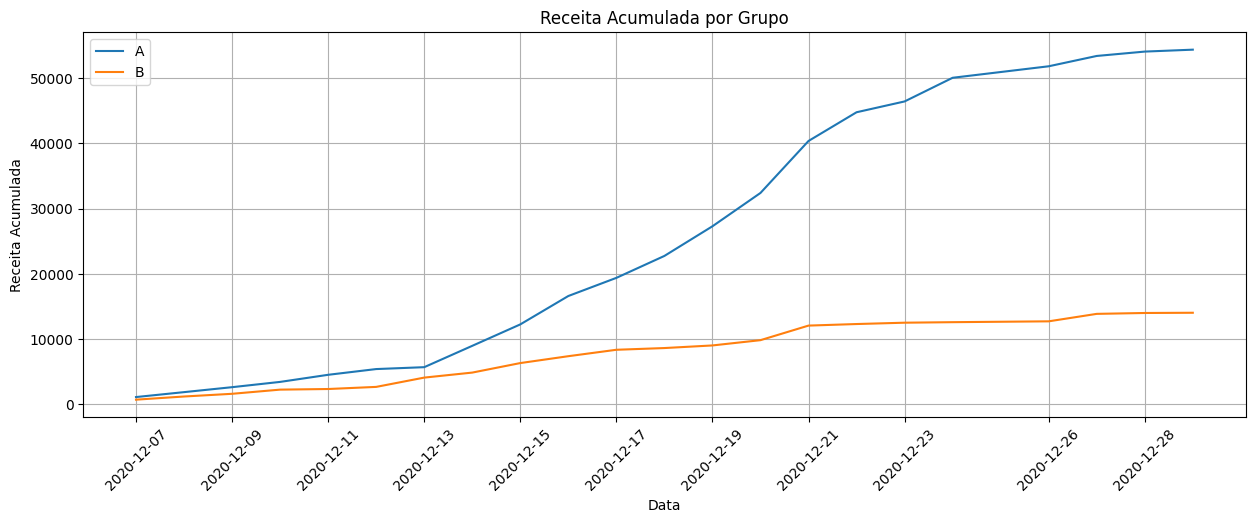

In [44]:
#Construindo gráfico de receita cumulativa diária para cada grupo.
plt.figure(figsize=(15, 5))
plt.plot(cumulativeRevenueA['event_date'], cumulativeRevenueA['cumulative_revenue'], label='A')
plt.plot(cumulativeRevenueB['event_date'], cumulativeRevenueB['cumulative_revenue'], label='B')
plt.title("Receita Acumulada por Grupo")
plt.grid()
plt.xticks(cumulativeRevenueA['event_date'][::2], rotation=45)
plt.xlabel("Data")
plt.ylabel("Receita Acumulada")

plt.legend()
plt.show()

---
Desde o início do experimento, a curva do Grupo A permanece consistentemente acima da curva do Grupo B em todo o período analisado.
Não há pontos de cruzamento entre as curvas, indicando uma vantagem clara e contínua do Grupo A ao longo do tempo. A diferença entre as curvas surge nos primeiros dias e se amplia de forma contínua, sugerindo um impacto significativo da variação aplicada ao Grupo A.

## 3.2. Ticket Médio Acumulado

In [45]:
# contando número de compras por grupo e dia
daily_purchases = (
    purchases
    .groupby(['group', 'event_date'])
    .size()
    .reset_index(name='daily_purchases')
)


In [46]:
# adicionando a quantidade diária de compras ao daily_revenue
daily_revenue = daily_revenue.merge(
    daily_purchases,
    on=['group', 'event_date'],
    how='left'
)
# ordenando para garantir cálculo correto
daily_revenue = daily_revenue.sort_values(['group', 'event_date'])

# criando compras acumuladas
daily_revenue['cumulative_purchases'] = (
    daily_revenue
    .groupby('group')['daily_purchases']
    .cumsum()
)
# calculando ticket médio acumulado
daily_revenue['avg_ticket_cumulative'] = (
    daily_revenue['cumulative_revenue'] /
    daily_revenue['cumulative_purchases']
)


In [47]:
#armazenando os dados relativos a datas, receita e quantidade de pedidos para os grupos A e B
cumulativeRevenueA = daily_revenue[daily_revenue['group']=='A'][
    ['group',
     'event_date',
     'cumulative_revenue',
     'cumulative_purchases',
     'avg_ticket_cumulative']
    ]
cumulativeRevenueB = daily_revenue[daily_revenue['group']=='B'][
    ['group',
     'event_date',
     'cumulative_revenue',
     'cumulative_purchases',
     'avg_ticket_cumulative']]

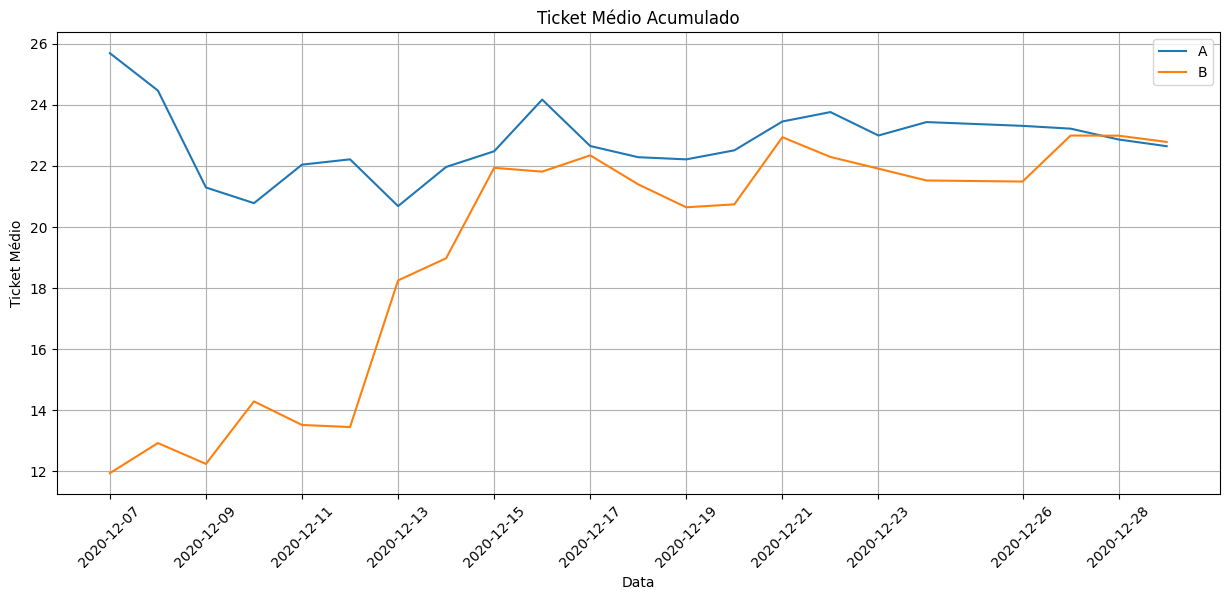

In [48]:
#constuindo gráfico do tamanho médio acumulado do pedido por grupo
plt.figure(figsize=(15, 6))

plt.plot(cumulativeRevenueA['event_date'],
         cumulativeRevenueA['avg_ticket_cumulative'],
         label='A')
plt.plot(cumulativeRevenueB['event_date'],
         cumulativeRevenueB['avg_ticket_cumulative'],
         label='B')
plt.grid()
plt.title('Ticket Médio Acumulado')
plt.xlabel("Data")
plt.ylabel("Ticket Médio")
plt.xticks(cumulativeRevenueA['event_date'][::2], rotation=45)

plt.legend()
plt.show()

---
O grupo A apresenta um ticket médio acumulado mais elevado no início do experimento, porém relativamente estável ao longo do tempo. Já o grupo B começa com valores significativamente menores, mas apresenta crescimento consistente, convergindo para níveis semelhantes aos do grupo A. Ao final do período analisado, ambos os grupos exibem tickets médios acumulados muito próximos, indicando ausência de diferença relevante no comportamento final de gasto médio por pedido.

## 3.3. Diferença Relativa do Ticket Médio Acumulado

In [49]:
# separando A e B
avg_ticket_A = cumulativeRevenueA[['event_date', 'avg_ticket_cumulative']].rename(
    columns={'avg_ticket_cumulative': 'avg_ticket_A'}
)

avg_ticket_B = cumulativeRevenueB[['event_date', 'avg_ticket_cumulative']].rename(
    columns={'avg_ticket_cumulative': 'avg_ticket_B'}
)

# juntando por data
avg_ticket_merged = avg_ticket_A.merge(
    avg_ticket_B,
    on='event_date',
    how='inner'
)

In [50]:
# calculando a diferença relativa B vs A
avg_ticket_merged['relative_diff'] = ((
    avg_ticket_merged['avg_ticket_B'] /
    avg_ticket_merged['avg_ticket_A'] - 1)*100 #transformando em porcento
)

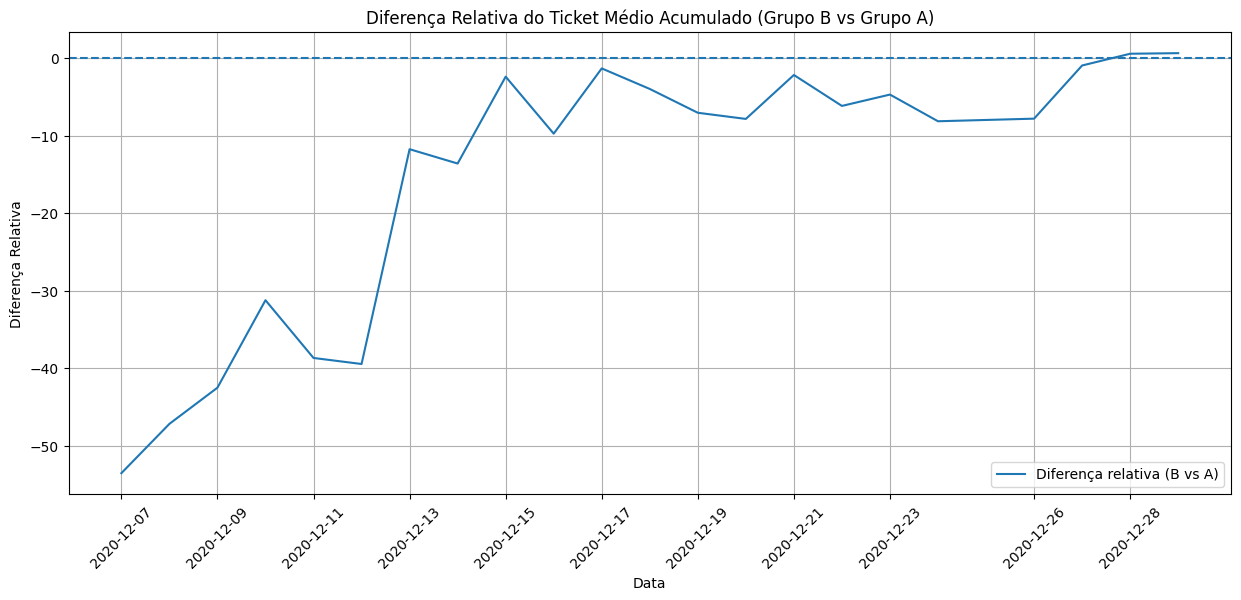

In [51]:
#Construir o gráfico

plt.figure(figsize=(15, 6))

plt.plot(
    avg_ticket_merged['event_date'],
    avg_ticket_merged['relative_diff'],
    label='Diferença relativa (B vs A)')

# linha de referência no zero
plt.axhline(y=0, linestyle='--')

plt.grid()
plt.title('Diferença Relativa do Ticket Médio Acumulado (Grupo B vs Grupo A)')
plt.xlabel('Data')
plt.ylabel('Diferença Relativa')

plt.xticks(
    avg_ticket_merged['event_date'][::2],
    rotation=45
)

plt.legend()
plt.show()


**Início do teste (07/12 a ~12/12)**

* O grupo B tem um ticket médio acumulado **muito menor** que o A
* Comportamento típico de início de experimento:

    * poucos pedidos
    * alta volatilidade
    * efeito de usuários iniciais

**Meio do teste (13/12 a ~20/12)**

* A curva sobe gradualmente
* Há uma inclinação positiva clara, porém, ainda abaixo de zero

**Fim do teste (21/12 a 29/12)**

* A curva oscila **próxima de zero**
* Nos últimos dias:

  * cruza o zero
  * chega a valores **ligeiramente positivos** (~+0,5% a +0,6%)
  * O grupo B **alcança** o grupo A, mas **não o supera de forma consistente**

Conclusão:

> O grupo B inicia o experimento com um ticket médio acumulado significativamente inferior ao grupo A. Ao longo do tempo, essa diferença diminui de forma consistente, indicando estabilização do comportamento dos usuários. No final do período, a diferença relativa se aproxima de zero, sugerindo que o novo sistema de recomendação não gera impacto relevante no tamanho médio acumulado do pedido em comparação ao grupo de controle.

## 3.4. Taxa de Conversão de cada grupo

In [52]:
data_events.head(3)

,user_id,event_dt,event_name,details,first_date,days_since_signup,group
0,831887FE7F2D6CBA,2020-12-07 06:50:29,purchase,4.99,2020-12-07,0,A
1,3C5DD0288AC4FE23,2020-12-07 19:42:40,purchase,4.99,2020-12-07,0,A
2,49EA242586C87836,2020-12-07 06:31:24,purchase,99.99,2020-12-07,0,B


A primeira vista, entende-se que todo usuário que realizou `purchase` obrigatoriamente precisa passar por `product_page`.

In [53]:
# verificando se há usuários que compraram mas nunca tiveram product_page
buyers = set(data_events[data_events['event_name'] == 'purchase']['user_id'])
visitors = set(data_events[data_events['event_name'] == 'product_page']['user_id'])

buyers_without_page = buyers - visitors
len(buyers_without_page)

348

Identificou-se que uma parcela dos usuários realizou compras sem registro prévio de visualização da página do produto, indicando limitações de rastreamento ou acessos diretos ao checkout. Para capturar adequadamente esse comportamento e evitar viés na taxa de conversão, considerou-se como visita qualquer usuário que realizou os eventos `product_page` ou `product_cart` ou `login`. Essa abordagem garante uma mensuração mais abrangente da conversão sem comprometer a consistência do funil.

In [54]:
# verificando usuários que compraram mas nunca tiveram product_page, product_cart ou login
buyers = set(data_events[data_events['event_name'] == 'purchase']['user_id'])
visitors = set(data_events[(data_events['event_name'] == 'product_cart') 
    | (data_events['event_name'] == 'product_page')
    | (data_events['event_name'] == 'login')]
    ['user_id']
              )

buyers_without_page = buyers - visitors
len(buyers_without_page)

1

In [55]:
# criando coluna de data
data_events['event_date'] = data_events['event_dt'].dt.date

# filtrando visitas (product_page)
daily_visits = ((data_events[(data_events['event_name'] == 'product_cart')
    | (data_events['event_name'] == 'product_page')
    | (data_events['event_name'] == 'login')])
    .groupby(['group', 'event_date'])
    .agg(visits=('user_id', 'nunique'))
    .reset_index()
)


In [56]:
# filtrando compras
daily_purchases = (
    data_events[data_events['event_name'] == 'purchase']
    .groupby(['group', 'event_date'])
    .agg(purchases=('user_id', 'nunique'))
    .reset_index()
)


In [57]:
# juntando visitas e compras
daily_conversion = daily_visits.merge(
    daily_purchases,
    on=['group', 'event_date'],
    how='left'
)


In [58]:
# dias sem compra recebem 0
daily_conversion['purchases'] = daily_conversion['purchases'].fillna(0)

# calculando taxa de conversão
daily_conversion['conversion_rate'] = (
    daily_conversion['purchases'] / daily_conversion['visits']
)
daily_conversion.head()

,group,event_date,visits,purchases,conversion_rate
0,A,2020-12-07,148,43,0.290541
1,A,2020-12-08,146,33,0.226027
2,A,2020-12-09,171,47,0.274854
3,A,2020-12-10,156,42,0.269231
4,A,2020-12-11,176,40,0.227273


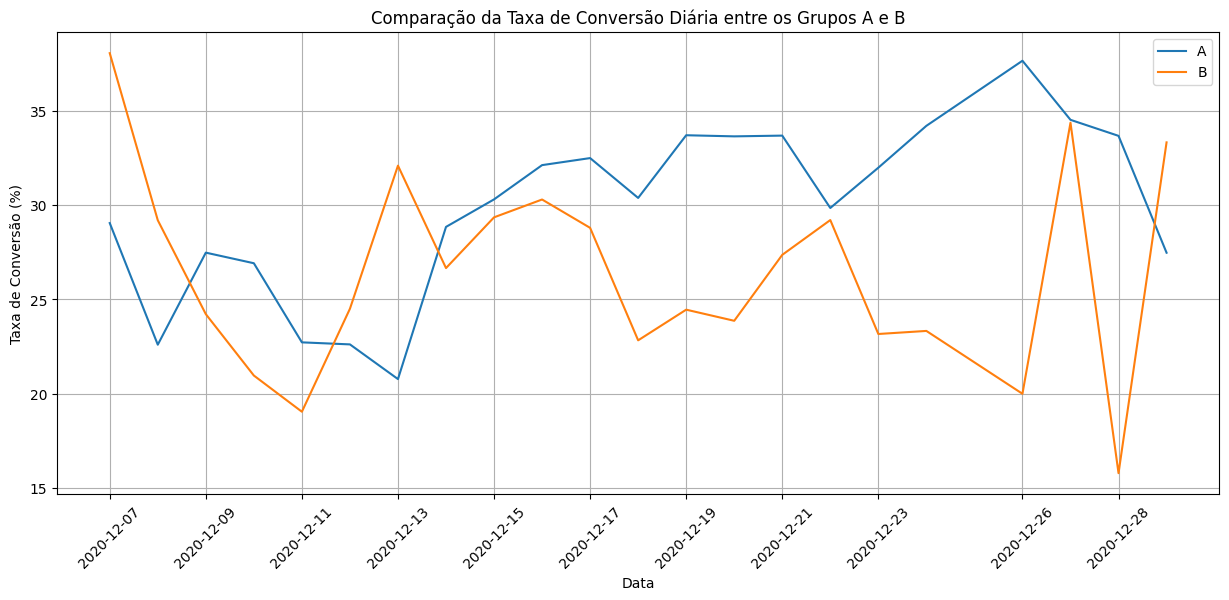

In [59]:
#armazenando os dados relativos a pedidos nos segmentos A e B
conversionDataA = daily_conversion[daily_conversion['group']=='A'] 
conversionDataB = daily_conversion[daily_conversion['group']=='B']

#gráfico de conversão diária cumulativa para cada grupo
plt.figure(figsize=(15, 6))

plt.plot(conversionDataA['event_date'], 
         conversionDataA['conversion_rate']*100, #transformando em porcentagem 
         label='A')
plt.plot(conversionDataB['event_date'], 
         conversionDataB['conversion_rate']*100, #transformando em porcentagem
         label='B')
plt.grid()
plt.xticks(rotation=45)
plt.title("Comparação da Taxa de Conversão Diária entre os Grupos A e B")
plt.xlabel("Data")
plt.ylabel("Taxa de Conversão (%)")
plt.legend()
plt.xticks(
    conversionDataA['event_date'][::2],
    rotation=45
)
plt.show()

**Conversão do Grupo A é mais estável e crescente**
* O grupo **A** apresenta:

  * Tendência clara de **crescimento ao longo do tempo**
  * Menor volatilidade após o dia **2020-12-14**
  * A conversão sai de ~22–29% no início e passa a operar frequentemente **acima de 32–34%** no fim do período.

**Conversão do Grupo B é mais volátil**
* O grupo **B** apresenta:

  * Oscilações bruscas de conversão (ex.: 38%, 19%, 32%)
  * Mesmo quando a conversão é alta (ex.: 34% em 27/12), ela **não se sustenta** nos dias seguintes.


**Conclusão**

> A taxa de conversão diária do grupo A apresenta crescimento progressivo e maior estabilidade ao longo do período analisado, especialmente após o aumento do volume de visitas. Já o grupo B mostra maior volatilidade, com picos pontuais de conversão que não se sustentam ao longo do tempo, possivelmente influenciados por baixo volume de tráfego. Visualmente e operacionalmente, **o grupo A demonstra desempenho mais consistente e robusto**, sendo a opção preferível do ponto de vista de negócio.

## 3.5. Diferença Relativa na Conversão Cumulativa

In [60]:
conversionDataA.head(3)

,group,event_date,visits,purchases,conversion_rate
0,A,2020-12-07,148,43,0.290541
1,A,2020-12-08,146,33,0.226027
2,A,2020-12-09,171,47,0.274854


In [61]:
#Juntando as tabelas convesionDataA e conversionDataB, de modo que a tabela resultante contenha as colunas ['date', 'conversionA', 'conversionB'] 
mergedCumulativeConversions = conversionDataA[['event_date','conversion_rate']].merge(
    conversionDataB[['event_date','conversion_rate']] , left_on=['event_date'], right_on=['event_date'], suffixes=['A','B']
)
mergedCumulativeConversions.head(3)

,event_date,conversion_rateA,conversion_rateB
0,2020-12-07,0.290541,0.380645
1,2020-12-08,0.226027,0.292035
2,2020-12-09,0.274854,0.242236


In [62]:
#calculando a diferença relativa na conversão cumulativa 
mergedCumulativeConversions['relative_diff_B_A'] = mergedCumulativeConversions['conversion_rateB']/ mergedCumulativeConversions['conversion_rateA']-1
mergedCumulativeConversions.head(3)

,event_date,conversion_rateA,conversion_rateB,relative_diff_B_A
0,2020-12-07,0.290541,0.380645,0.310128
1,2020-12-08,0.226027,0.292035,0.292035
2,2020-12-09,0.274854,0.242236,-0.118673


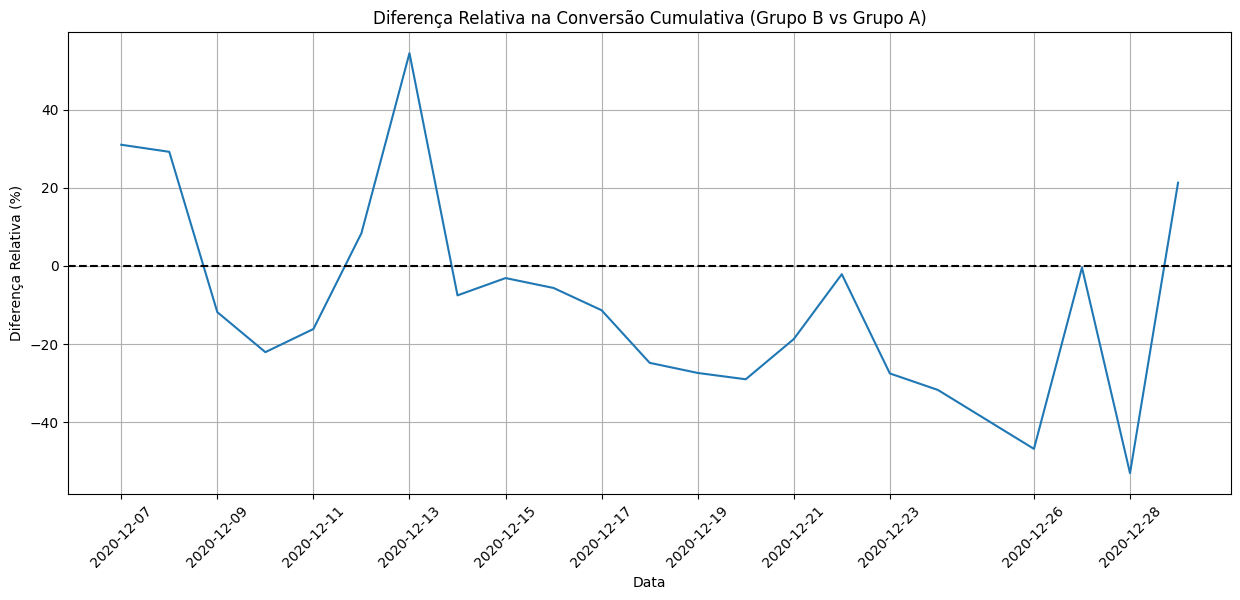

In [63]:
# gráfico com a diferença relativa entre a taxa de conversão cumulativa do grupo B comparada com o grupo A
plt.figure(figsize=(15, 6))

plt.plot(mergedCumulativeConversions['event_date'],
        (mergedCumulativeConversions['relative_diff_B_A']
        )*100 #transformando em porcentagem
        )
plt.grid()
plt.title("Diferença Relativa na Conversão Cumulativa (Grupo B vs Grupo A)")
plt.xticks(rotation=45)
plt.xlabel("Data")
plt.ylabel("Diferença Relativa (%)")
plt.axhline(y=0, color='black', linestyle='--')
#definição de escala dos eixos
plt.xticks(mergedCumulativeConversions['event_date'][::2])
plt.show()

* **> 0** : Grupo **B** converte melhor que **A**
* **< 0** : Grupo **B** converte pior que **A**
* **= 0** : Conversões equivalentes


**Vantagem inicial do grupo B não se sustenta**

* Nos primeiros dias (07/12 e 08/12) há uma diferença relativa **positiva**
  * Grupo B chega a converter **~30% melhor** que o grupo A
* Esse efeito **desaparece rapidamente**

**Predominância de valores negativos ao longo do tempo**

* A partir de 09/12 a curva passa a ficar **majoritariamente abaixo de 0**
* Entre 14/12 e 28/12 a diferença relativa frequentemente entre **−20% e −50%**

* *Isso indica que, **na maior parte do experimento**, o grupo B converte **pior** que o grupo A.*


**Conclusão**

> O gráfico da diferença relativa na conversão cumulativa mostra que, embora o grupo B apresente vantagem inicial, esse efeito não se sustenta ao longo do tempo. Na maior parte do experimento, a conversão do grupo B é inferior à do grupo A, com quedas expressivas e alta volatilidade. A ausência de convergência e **a predominância de valores negativos indicam que o grupo A apresenta desempenho mais consistente e robusto**, sendo a opção preferível do ponto de vista de negócio.



## 3.6. Verificação de outliers de pedidos por usuário

In [64]:
purchases.head(3)

,user_id,event_dt,event_name,details,first_date,days_since_signup,group,event_date
0,831887FE7F2D6CBA,2020-12-07 06:50:29,purchase,4.99,2020-12-07,0,A,2020-12-07
1,831887FE7F2D6CBA,2020-12-09 02:19:17,purchase,99.99,2020-12-07,2,A,2020-12-09
2,3C5DD0288AC4FE23,2020-12-07 19:42:40,purchase,4.99,2020-12-07,0,A,2020-12-07


In [65]:
# cálculo da quantidade de pedidos por usuário 
ordersByUsers = (
    purchases.drop(['event_dt', 'details', 'first_date','days_since_signup','group','event_date'], axis=1)
    .groupby('user_id', as_index=False)
    .agg({'event_name': pd.Series.nunique})
)
ordersByUsers.describe()

,event_name
count,1082.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


A análise da quantidade de pedidos por usuário mostra que todos os compradores realizaram exatamente um pedido, sem qualquer variação. Isso indica ausência total de outliers relacionados à frequência de compra.

## 3.7. Percentis 95, 98 e 99 dos preços dos pedidos

In [66]:
print('Percentis 95, 98 e 99 dos preços de todos os pedidos:', np.percentile(purchases['details'],[95,98,99]))
print('Percentis 95, 98 e 99 dos preços do pedidos do grupo A:', np.percentile(purchases[purchases['group']=='A']['details'],[95,98,99]))
print('Percentis 95, 98 e 99 dos preços do pedidos do grupo B:', np.percentile(purchases[purchases['group']=='B']['details'],[95,98,99]))

Percentis 95, 98 e 99 dos preços de todos os pedidos: [ 99.99  99.99 499.99]
Percentis 95, 98 e 99 dos preços do pedidos do grupo A: [ 99.99  99.99 499.99]
Percentis 95, 98 e 99 dos preços do pedidos do grupo B: [ 99.99  99.99 499.99]


* **Até 98% dos pedidos custam no máximo 99,99**
* Apenas **~1% dos pedidos chegam a 499,99** (claramente extremo)
* Não há diferença estrutural entre A e B na distribuição de preços

> Como cada usuário só fez **1 pedido**, um único pedido de 499,99, desloca o ticket médio, gera “saltos” visuais nos gráficos e aumenta volatilidade nas curvas iniciais.

In [67]:
# definindo limite de outliers (percentil 98)
price_threshold = 99.99

# criando dataset de pedidos sem outliers
purchases_clean = purchases[purchases['details'] <= price_threshold]

In [68]:
print('Pedidos antes:', purchases.shape[0])
print('Pedidos depois (sem outliers):', purchases_clean.shape[0])

Pedidos antes: 3018
Pedidos depois (sem outliers): 2965


## 3.8. Receita Acumulada sem Outliers

In [69]:
# recalculando receita diária por grupo
daily_revenue_clean = (
    purchases_clean
    .groupby(['group', 'event_date'])['details']
    .sum()
    .reset_index()
    .rename(columns={'details': 'daily_revenue'})
)

# ordenando por grupo e data
daily_revenue_clean = daily_revenue_clean.sort_values(['group', 'event_date'])

# receita acumulada
daily_revenue_clean['cumulative_revenue'] = (
    daily_revenue_clean
    .groupby('group')['daily_revenue']
    .cumsum()
)

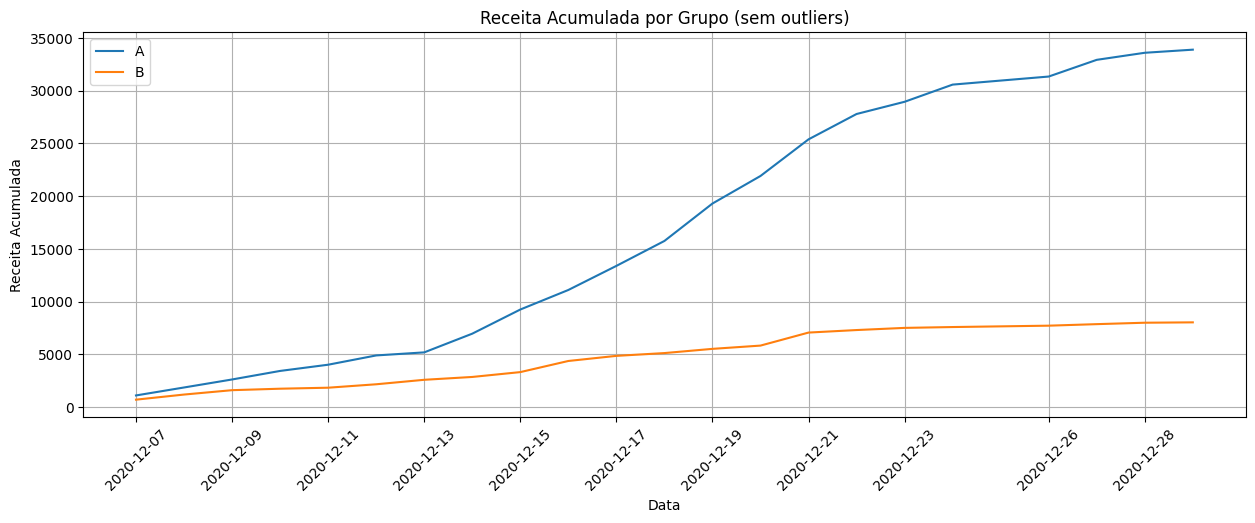

In [70]:
#armazenando os dados relativos a datas e receita para os grupos A e B
clean_cumulativeRevenueA = daily_revenue_clean[daily_revenue_clean['group']=='A'][['event_date','cumulative_revenue']]
clean_cumulativeRevenueB = daily_revenue_clean[daily_revenue_clean['group']=='B'][['event_date','cumulative_revenue']]

#Construindo gráfico de receita cumulativa diária para cada grupo.
plt.figure(figsize=(15, 5))
plt.plot(clean_cumulativeRevenueA['event_date'], clean_cumulativeRevenueA['cumulative_revenue'], label='A')
plt.plot(clean_cumulativeRevenueB['event_date'], clean_cumulativeRevenueB['cumulative_revenue'], label='B')
plt.title("Receita Acumulada por Grupo (sem outliers)")
plt.grid()
plt.xticks(clean_cumulativeRevenueA['event_date'][::2], rotation=45)
plt.xlabel("Data")
plt.ylabel("Receita Acumulada")

plt.legend()
plt.show()

Os dois gráficos, com e sem outliers, mostram o mesmo comportamento geral (Grupo A sempre acima do Grupo B), mas com diferenças importantes na **escala, inclinação e picos**.

**Receita Acumulada por grupo (sem outliers)**

* O crescimento do **Grupo A** continua maior que o B, mas de forma **mais suave e linear**.
* O acumulado final do A fica em torno de **34.000** (bem menor que os 55.000 anteriores).
* A inclinação das curvas é mais estável, sem saltos tão abruptos.
* Mesmo sem outliers, o **Grupo A continua performando melhor**.

**Conclusão** 

> A superioridade do Grupo A é consistente, mas os outliers ampliam significativamente essa vantagem. Portanto, o Grupo A apresenta melhor desempenho geral, porém parte da diferença observada no gráfico original é influenciada por pedidos de valor 499, excepcionalmente altos.

## 3.9. Ticket Médio Acumulado sem Outliers

In [71]:
# recalculando compras diárias
daily_purchases_clean = (
    purchases_clean
    .groupby(['group', 'event_date'])
    .size()
    .reset_index(name='daily_purchases')
)
# adicionando a quantidade diária de compras ao daily_revenue
daily_revenue_clean = daily_revenue_clean.merge(
    daily_purchases_clean,
    on=['group', 'event_date'],
    how='left'
)
# ordenando para garantir cálculo correto
daily_revenue_clean = daily_revenue_clean.sort_values(['group', 'event_date'])

# compras acumuladas
daily_revenue_clean['cumulative_purchases'] = (
    daily_revenue_clean
    .groupby('group')['daily_purchases']
    .cumsum()
)

# ticket médio acumulado
daily_revenue_clean['avg_ticket_cumulative'] = (
    daily_revenue_clean['cumulative_revenue'] /
    daily_revenue_clean['cumulative_purchases']
)

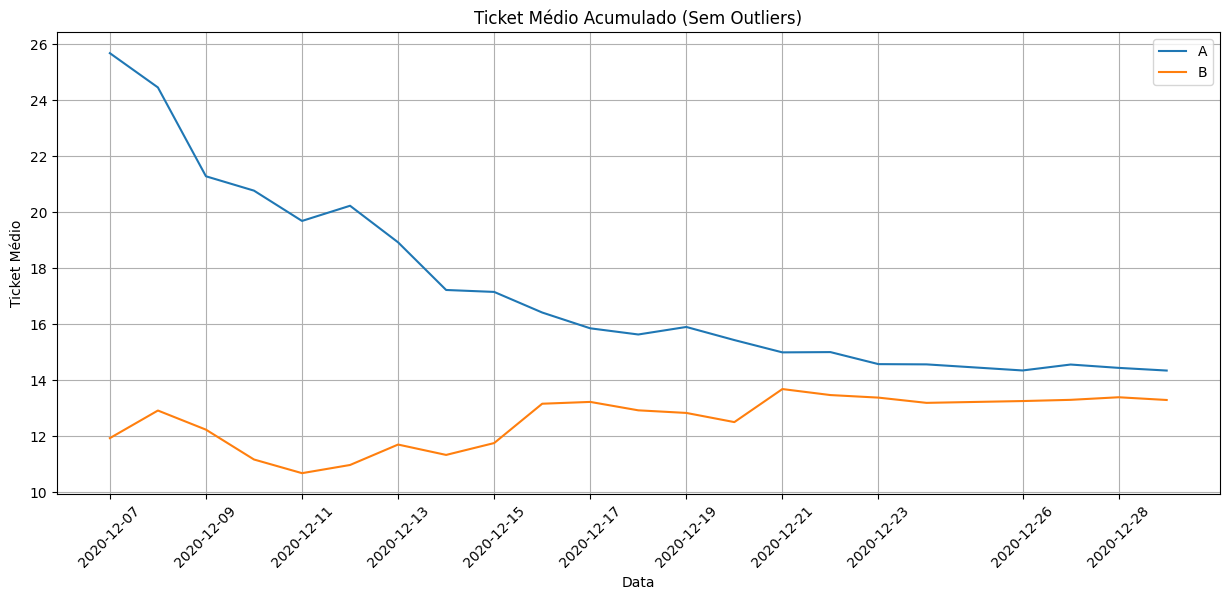

In [72]:
# Gráfico do ticket médio acumulado (limpo)

ticketA = daily_revenue_clean[daily_revenue_clean['group'] == 'A']
ticketB = daily_revenue_clean[daily_revenue_clean['group'] == 'B']

plt.figure(figsize=(15, 6))

plt.plot(ticketA['event_date'], ticketA['avg_ticket_cumulative'], label='A')
plt.plot(ticketB['event_date'], ticketB['avg_ticket_cumulative'], label='B')

plt.grid()
plt.title('Ticket Médio Acumulado (Sem Outliers)')
plt.xlabel('Data')
plt.ylabel('Ticket Médio')
plt.xticks(ticketA['event_date'][::2], rotation=45)
plt.legend()
plt.show()

* O **Grupo A** começa com ticket médio bem mais alto e apresenta **queda gradual ao longo do tempo**, saindo de ~26 para ~14.
* O **Grupo B** mantém um ticket médio **mais baixo e estável**, variando aproximadamente entre 11 e 13,5.
* A distância entre A e B é **clara e consistente** durante quase todo o período.
* As curvas são mais **suaves**, sem picos abruptos.
* **Com outliers**, o ticket médio do Grupo B é artificialmente inflado, reduzindo a diferença visual entre os grupos. **Sem outliers**, o Grupo A tem ticket médio consistentemente maior. 

Conclusão:
> O Grupo A mantém um ticket médio superior de forma consistente. Os outliers elevam momentaneamente o ticket médio do Grupo B, mas não alteram a conclusão principal: a diferença observada é estrutural e o desempenho do Grupo A é mais sólido quando analisamos o padrão real de consumo.

## 3.10. Diferença Reltiva do Ticket Médio Acumulado sem Outliers

In [73]:
#  juntando A e B
avg_ticket_clean = ticketA[['event_date', 'avg_ticket_cumulative']].merge(
    ticketB[['event_date', 'avg_ticket_cumulative']],
    on='event_date',
    suffixes=('_A', '_B')
)

# diferença relativa
avg_ticket_clean['relative_diff'] = (
    avg_ticket_clean['avg_ticket_cumulative_B'] /
    avg_ticket_clean['avg_ticket_cumulative_A'] - 1
) * 100

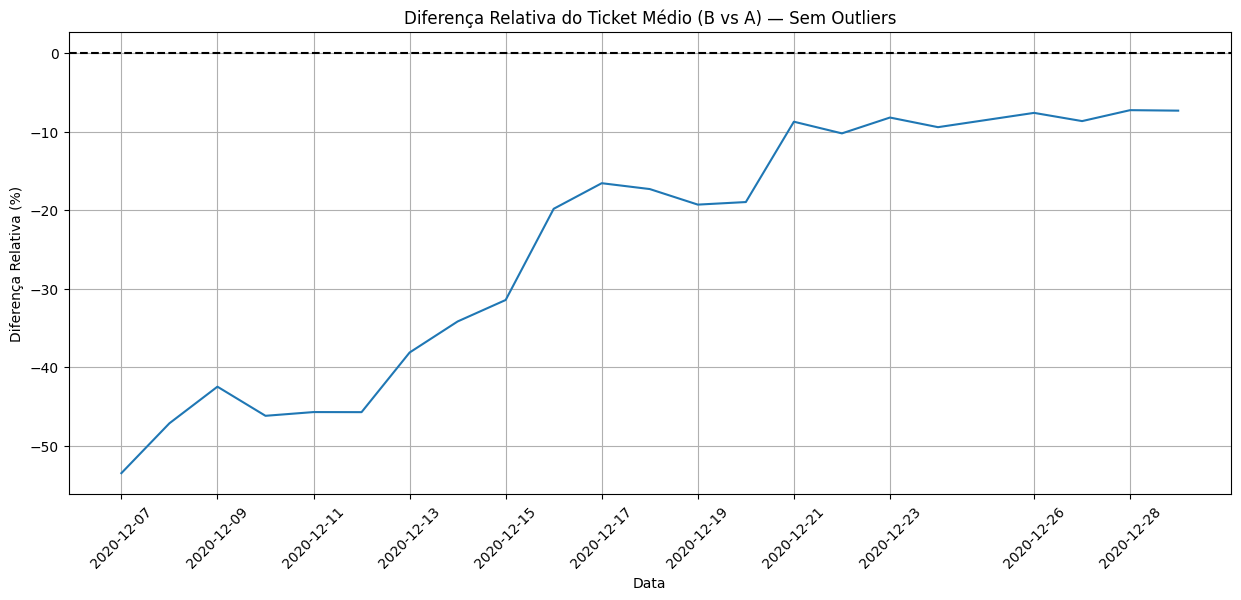

In [74]:
plt.figure(figsize=(15, 6))

plt.plot(avg_ticket_clean['event_date'], avg_ticket_clean['relative_diff'])
plt.axhline(y=0, color='black', linestyle='--')
plt.grid()

plt.title('Diferença Relativa do Ticket Médio (B vs A) — Sem Outliers')
plt.xlabel('Data')
plt.ylabel('Diferença Relativa (%)')
plt.xticks(avg_ticket_clean['event_date'][::2], rotation=45)
plt.show()

* A diferença entre o grupo B e A começa muito negativa (próximo de -50%).
* A curva nunca atinge o zero.
* No final do período, a diferença permanece em torno de **-7% a -10%**

* **Com outliers**, o Grupo B aparenta quase igualar o ticket médio do Grupo A no final do período. **Sem outliers**, fica claro que o Grupo B melhora ao longo do tempo, mas **permanece consistentemente abaixo do Grupo A**.

Conclusão:

> A aproximação observada no gráfico original é em grande parte influenciada por pedidos de alto valor. Quando analisamos o comportamento típico dos clientes, o Grupo A mantém ticket médio superior de forma consistente. Embora os outliers **aumentem artificialmente a diferença relativa**, a vantagem de desempenho permanece com o Grupo A.

## 3.11. Taxa de Conversão de cada grupo sem Outliers

In [75]:
daily_visits.head(3)

,group,event_date,visits
0,A,2020-12-07,148
1,A,2020-12-08,146
2,A,2020-12-09,171


In [76]:
# juntando visitas e compras sem outliers
daily_conversion_clean = daily_visits.merge(
    daily_purchases_clean,
    on=['group', 'event_date'],
    how='left'
)

In [77]:
# dias sem compra recebem 0
daily_conversion_clean['daily_purchases'] = daily_conversion_clean['daily_purchases'].fillna(0)

# calculando taxa de conversão
daily_conversion_clean['conversion_rate'] = (
    daily_conversion_clean['daily_purchases'] / daily_conversion_clean['visits']
)
daily_conversion_clean.head(3)

,group,event_date,visits,daily_purchases,conversion_rate
0,A,2020-12-07,148,43,0.290541
1,A,2020-12-08,146,33,0.226027
2,A,2020-12-09,171,47,0.274854


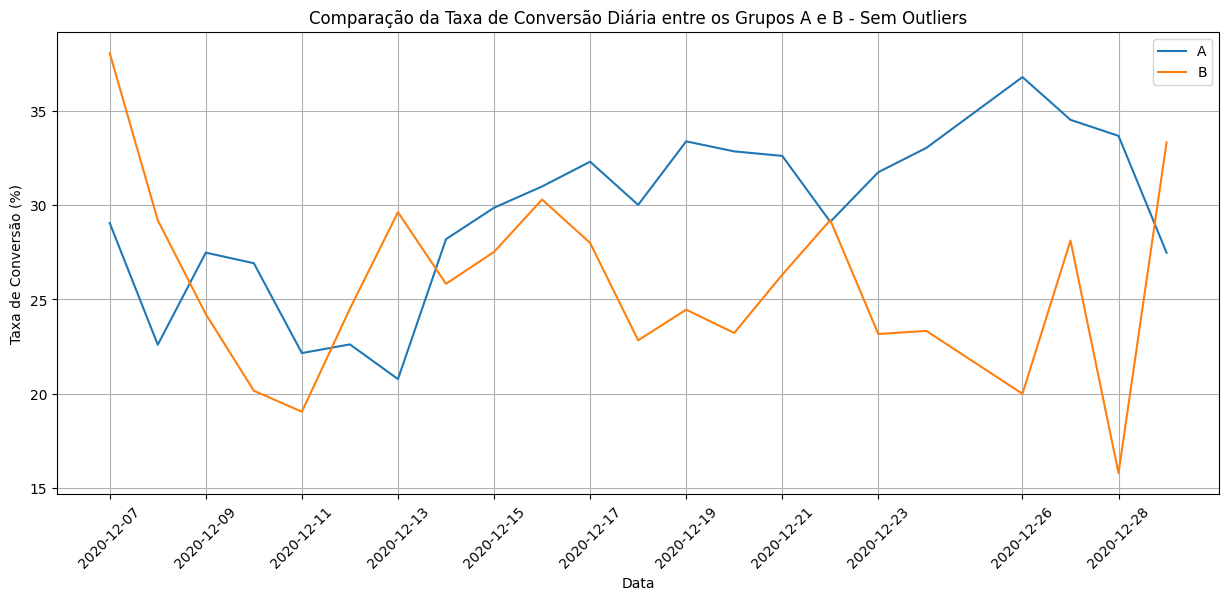

In [78]:
#armazenando os dados relativos a pedidos nos segmentos A e B
conversionData_cleanA = daily_conversion_clean[daily_conversion_clean['group']=='A'] 
conversionData_cleanB = daily_conversion_clean[daily_conversion_clean['group']=='B']

#gráfico de conversão diária cumulativa para cada grupo
plt.figure(figsize=(15, 6))

plt.plot(conversionData_cleanA['event_date'], 
         conversionData_cleanA['conversion_rate']*100, #transformando em porcentagem 
         label='A')
plt.plot(conversionData_cleanB['event_date'], 
         conversionData_cleanB['conversion_rate']*100, #transformando em porcentagem
         label='B')
plt.grid()
plt.xticks(rotation=45)
plt.title("Comparação da Taxa de Conversão Diária entre os Grupos A e B - Sem Outliers")
plt.xlabel("Data")
plt.ylabel("Taxa de Conversão (%)")
plt.legend()
plt.xticks(
    conversionData_cleanA['event_date'][::2],
    rotation=45
)
plt.show()

* A remoção de outliers **não altera significativamente o padrão da conversão**.
* A volatilidade extrema do Grupo B diminui levemente, mas os picos e quedas continuam visíveis.
* O **Grupo A mantém comportamento mais estável e consistente**.
* A vantagem do Grupo A na segunda metade do período continua clara.

Conclusão

> A remoção de outliers não altera significativamente o comportamento da taxa de conversão. Isso confirma que o desempenho superior do Grupo A não está relacionado a pedidos de alto valor isolados, mas sim a uma conversão estruturalmente mais eficiente ao longo do período.

## 3.12. Diferença Relativa na Conversão Cumulativa sem Outliers

In [79]:
#Juntando as tabelas conversionData_cleanA e conversionData_cleanB, de modo que a tabela resultante contenha as colunas ['date', 'conversionA', 'conversionB'] 
mergedCumulativeConversions_clean = conversionData_cleanA[['event_date','conversion_rate']].merge(
    conversionData_cleanB[['event_date','conversion_rate']] , left_on=['event_date'], right_on=['event_date'], suffixes=['A','B']
)
mergedCumulativeConversions_clean.head(3)

,event_date,conversion_rateA,conversion_rateB
0,2020-12-07,0.290541,0.380645
1,2020-12-08,0.226027,0.292035
2,2020-12-09,0.274854,0.242236


In [80]:
#calculando a diferença relativa na conversão cumulativa 
mergedCumulativeConversions_clean['relative_diff_B_A'] = mergedCumulativeConversions_clean['conversion_rateB']/ mergedCumulativeConversions_clean['conversion_rateA']-1
mergedCumulativeConversions_clean.head(3)

,event_date,conversion_rateA,conversion_rateB,relative_diff_B_A
0,2020-12-07,0.290541,0.380645,0.310128
1,2020-12-08,0.226027,0.292035,0.292035
2,2020-12-09,0.274854,0.242236,-0.118673


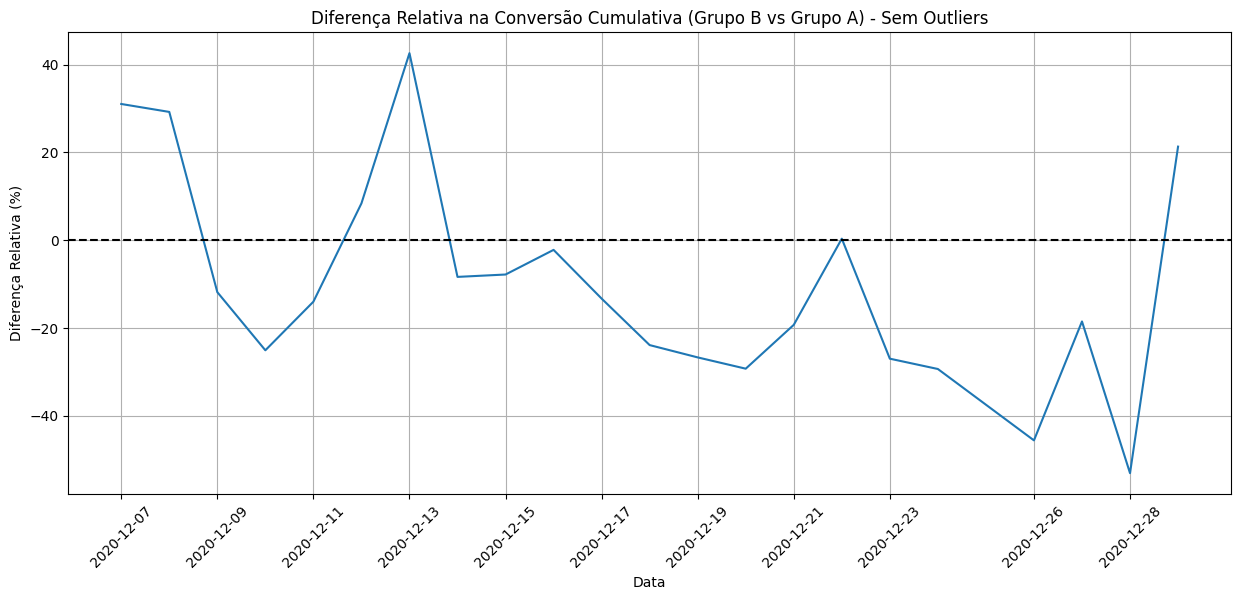

In [81]:
# gráfico com a diferença relativa entre a taxa de conversão cumulativa do grupo B comparada com o grupo A
plt.figure(figsize=(15, 6))

plt.plot(mergedCumulativeConversions_clean['event_date'],
        (mergedCumulativeConversions_clean['relative_diff_B_A']
        )*100 #transformando em porcentagem
        )
plt.grid()
plt.title("Diferença Relativa na Conversão Cumulativa (Grupo B vs Grupo A) - Sem Outliers")
plt.xticks(rotation=45)
plt.xlabel("Data")
plt.ylabel("Diferença Relativa (%)")
plt.axhline(y=0, color='black', linestyle='--')
#definição de escala dos eixos
plt.xticks(mergedCumulativeConversions_clean['event_date'][::2])
plt.show()

A linha pontilhada em 0% representa igualdade entre os grupos.
Valores **positivos**: Grupo B converte melhor que A.
Valores **negativos**: Grupo A converte melhor que B.


* O comportamento é **quase idêntico** ao gráfico original. Os outliers não impactam significativamente a conversão cumulativa.
* A vantagem inicial do Grupo B não se sustenta. Apesar de picos positivos no início, o Grupo A passa a apresentar melhor desempenho na maior parte do período.

Conclusão

> A análise confirma que a diferença observada na conversão cumulativa não é resultado de valores extremos. Mesmo após remover outliers, o Grupo A apresenta desempenho mais consistente e tende a superar o Grupo B ao longo do tempo. Isso reforça que **a vantagem do Grupo A é estrutural e não causada por eventos pontuais**.


---
##### Os resultados do experimento indicam que o Grupo A apresentou desempenho superior ao Grupo B tanto em conversão quanto em ticket médio acumulado ao longo do período analisado.

##### Embora tenham sido identificados pedidos de alto valor, todos os usuários realizaram apenas um pedido, o que indica que esses casos representam clientes premium e não distorções comportamentais. A remoção desses valores reduziu a volatilidade das métricas, mas não alterou a conclusão geral.

##### Mesmo após o controle de outliers, o Grupo A manteve vantagem consistente, enquanto o Grupo B não apresentou melhoria estrutural nem atingiu ganho mínimo relevante no funil.

##### Dessa forma, não há evidências suficientes para recomendar a implementação da versão testada no Grupo B.


# 4. Teste Estatístico

## 4.1. Significância estatística da diferença na conversão entre os grupos usando os dados brutos

In [82]:
purchases.head()

,user_id,event_dt,event_name,details,first_date,days_since_signup,group,event_date
0,831887FE7F2D6CBA,2020-12-07 06:50:29,purchase,4.99,2020-12-07,0,A,2020-12-07
1,831887FE7F2D6CBA,2020-12-09 02:19:17,purchase,99.99,2020-12-07,2,A,2020-12-09
2,3C5DD0288AC4FE23,2020-12-07 19:42:40,purchase,4.99,2020-12-07,0,A,2020-12-07
3,49EA242586C87836,2020-12-07 06:31:24,purchase,99.99,2020-12-07,0,B,2020-12-07
4,49EA242586C87836,2020-12-09 15:39:47,purchase,9.99,2020-12-07,2,B,2020-12-09


In [83]:
# calcular compradores únicos por grupo
buyersA = purchases[purchases['group']=='A']['user_id'].nunique()
buyersB = purchases[purchases['group']=='B']['user_id'].nunique()
# Calcular visitantes únicos por grupo
visitorsA = data_events[
    (data_events['group']=='A') &
    (data_events['event_name'].isin(['product_page','product_cart','login']))
]['user_id'].nunique()

visitorsB = data_events[
    (data_events['group']=='B') &
    (data_events['event_name'].isin(['product_page','product_cart','login']))
]['user_id'].nunique()

In [84]:
# sucessos (compras)
successes = np.array([buyersA, buyersB])

# total de visitantes
trials = np.array([visitorsA, visitorsB])

stat, p_value = proportions_ztest(successes, trials)

print('p-value:', round(p_value,5))
print('Diferença relativa de conversão (B vs A):', round((buyersB/visitorsB)/(buyersA/visitorsA)-1,3))

alpha = 0.05

if p_value < alpha:
    print("Rejeitamos a hipótese nula: existe evidência estatística de diferença na conversão entre os grupos.")
else:
    print("Não rejeitamos a hipótese nula: não há evidência estatística suficiente de diferença na conversão.")

p-value: 0.04865
Diferença relativa de conversão (B vs A): -0.111
Rejeitamos a hipótese nula: existe evidência estatística de diferença na conversão entre os grupos.


* Rejeitamos a hipótese nula ao nível de 5% de significância. O resultado esperado é de que deveria *haver aumento mínimo de 10%*, mas a taxa de conversão do Grupo B é aproximadamente **11% menor que a do Grupo A**.

Conclusão:
> O teste estatístico para diferença de proporções indica que a taxa de conversão do Grupo B é significativamente inferior à do Grupo A (p = 0,0486). A diferença relativa observada é de aproximadamente -11%, indicando que o novo sistema testado não apenas falhou em melhorar a conversão, como apresentou desempenho inferior ao da versão original.

## 4.2. Significância estatística da diferença na conversão entre os grupos usando os dados filtrados

In [85]:
purchases_clean.head()

,user_id,event_dt,event_name,details,first_date,days_since_signup,group,event_date
0,831887FE7F2D6CBA,2020-12-07 06:50:29,purchase,4.99,2020-12-07,0,A,2020-12-07
1,831887FE7F2D6CBA,2020-12-09 02:19:17,purchase,99.99,2020-12-07,2,A,2020-12-09
2,3C5DD0288AC4FE23,2020-12-07 19:42:40,purchase,4.99,2020-12-07,0,A,2020-12-07
3,49EA242586C87836,2020-12-07 06:31:24,purchase,99.99,2020-12-07,0,B,2020-12-07
4,49EA242586C87836,2020-12-09 15:39:47,purchase,9.99,2020-12-07,2,B,2020-12-09


In [86]:
# calcular compradores únicos por grupo
buyersA_clean = purchases_clean[purchases_clean['group']=='A']['user_id'].nunique()
buyersB_clean = purchases_clean[purchases_clean['group']=='B']['user_id'].nunique()

In [87]:
# sucessos sem outliers (compras)
successes_clean = np.array([buyersA_clean, buyersB_clean])

stat, p_value_clean = proportions_ztest(successes_clean, trials)

print('p-value:', round(p_value,5))
print('Diferença relativa de conversão (B vs A):', round((buyersB_clean/visitorsB)/(buyersA_clean/visitorsA)-1,3))

alpha = 0.05

if p_value_clean < alpha:
    print("Rejeitamos a hipótese nula: existe evidência estatística de diferença na conversão entre os grupos.")
else:
    print("Não rejeitamos a hipótese nula: não há evidência estatística suficiente de diferença na conversão.")

p-value: 0.04865
Diferença relativa de conversão (B vs A): -0.112
Rejeitamos a hipótese nula: existe evidência estatística de diferença na conversão entre os grupos.


* O resultado é praticamente idêntico.
* Isso confirma que a diferença na conversão não é causada por pedidos de alto valor ou de clientes premium.

Conclusão:
> A análise estatística indica que a taxa de conversão do Grupo B é aproximadamente 11% inferior à do Grupo A, com diferença estatisticamente significativa ao nível de 5% (p ≈ 0,048). A remoção de pedidos de alto valor não altera esse resultado, indicando que o desempenho inferior do Grupo B é estrutural e não decorrente de valores extremos.

## 4.3. Significância estatística da diferença no ticket médio do pedido entre os grupos

Hipóteses:
* H0: As distribuições de ticket médio são iguais entre os grupos.
* H1: As distribuições são diferentes.

In [88]:
# valores de pedidos por grupo com dados brutos
ticketA = purchases[purchases['group']=='A']['details']
ticketB = purchases[purchases['group']=='B']['details']

# teste Mann-Whitney
stat, p_value = st.mannwhitneyu(ticketA, ticketB, alternative='two-sided')

print('p-value (com outliers):', round(p_value,5))
print('Diferença relativa média (B vs A):',
      round(ticketB.mean()/ticketA.mean()-1,3))
if p_value < alpha:
    print("Rejeitamos a hipótese nula: Existe evidência estatística de diferença no ticket médio com dados brutos.")
else:
    print("Não rejeitamos a hipótese nula: Não há evidência estatística suficiente da diferença no ticket médio com dados brutos.")

p-value (com outliers): 0.67724
Diferença relativa média (B vs A): 0.006
Não rejeitamos a hipótese nula: Não há evidência estatística suficiente da diferença no ticket médio com dados brutos.


In [89]:
# valores de pedidos por grupo com dados filtrados
ticketA_clean = purchases_clean[purchases_clean['group']=='A']['details']
ticketB_clean = purchases_clean[purchases_clean['group']=='B']['details']

# teste Mann-Whitney
stat_clean, p_value_clean = st.mannwhitneyu(
    ticketA_clean,
    ticketB_clean,
    alternative='two-sided'
)

print('p-value (sem outliers):', round(p_value_clean,5))
print('Diferença relativa média (B vs A):',
      round(ticketB_clean.mean()/ticketA_clean.mean()-1,3))
if p_value_clean < alpha:
    print("Rejeitamos a hipótese nula: Existe evidência estatística de diferença no ticket médio com dados filtrados.")
else:
    print("Não rejeitamos a hipótese nula: Não há evidência estatística suficiente da diferença no ticket médio com dados filtrados.")

p-value (sem outliers): 0.57274
Diferença relativa média (B vs A): -0.073
Não rejeitamos a hipótese nula: Não há evidência estatística suficiente da diferença no ticket médio com dados filtrados.


* Não possamos afirmar estatisticamente que existe diferença real no ticket médio entre os grupos.
> Isso mostra que o problema do Grupo B não está no valor do pedido mas sim na capacidade de converter visitantes em compradores.

## 4.4. Significância estatística da diferença nas proporções de usuários por etapa do funil entre os grupos

##### A porcentagem de usuários que chegam a cada etapa do funil é diferente entre os grupos A e B?
**H0**: A proporção de usuários que chegam a essa etapa do funil é igual nos grupos A e B.

> Não há efeito do experimento nessa etapa.

**H1**: A proporção de usuários que chegam a essa etapa do funil é diferente entre os grupos.

> O experimento impacta essa etapa do funil.

In [90]:
data_events.head()

,user_id,event_dt,event_name,details,first_date,days_since_signup,group,event_date
0,831887FE7F2D6CBA,2020-12-07 06:50:29,purchase,4.99,2020-12-07,0,A,2020-12-07
1,3C5DD0288AC4FE23,2020-12-07 19:42:40,purchase,4.99,2020-12-07,0,A,2020-12-07
2,49EA242586C87836,2020-12-07 06:31:24,purchase,99.99,2020-12-07,0,B,2020-12-07
3,2B06EB547B7AAD08,2020-12-07 21:36:38,purchase,4.99,2020-12-07,0,A,2020-12-07
4,A640F31CAC7823A6,2020-12-07 18:48:26,purchase,4.99,2020-12-07,0,B,2020-12-07


In [91]:
# Definir as etapas do funil
events = ['login', 'product_page', 'product_cart', 'purchase']

for event in events: 
    # Filtrar os dados para o evento e os grupos A e B
    event_data_A = data_events[
        (data_events['event_name'] == event) &
        (data_events['user_id'].isin(data_events[data_events['group'] == 'A']['user_id']))]
    
    event_data_B = data_events[
        (data_events['event_name'] == event) &
        (data_events['user_id'].isin(data_events[data_events['group'] == 'B']['user_id']))]
    
    
    # Contar o número de usuários que realizaram o evento em cada grupo
    event_count_A = len(event_data_A['user_id'].unique())
    event_count_B = len(event_data_B['user_id'].unique())
    
    # Contar o número total de usuários em cada grupo
    total_users_A = len(data_events[data_events['group'] == 'A'])
    total_users_B = len(data_events[data_events['group'] == 'B'])
    
    # Executar o teste z apenas se houver dados válidos
    count = np.array([event_count_A, event_count_B])
    nobs = np.array([total_users_A, total_users_B])
    z_score, p_value = proportions_ztest(count, nobs)
    
    # Imprimir os resultados
    print(f"Evento: {event}")
    print(f"Contagem Grupo A: {event_count_A}")
    print(f"Contagem Grupo B: {event_count_B}")
    print(f"Número Total de Usuários Grupo A: {total_users_A}")
    print(f"Número Total de Usuários Grupo B: {total_users_B}")
    print(f"Estatística do Teste z: {z_score}")
    print(f"Valor p: {p_value}")
    if p_value < 0.05: 
        print("Rejeitamos H0: Existe diferença estatisticamente significativa entre os grupos nessa etapa do funil.")
    else:
        print("Não rejeitamos H0: Não há evidência estatística de diferença nessa etapa.")
    print()

Evento: login
Contagem Grupo A: 2604
Contagem Grupo B: 876
Número Total de Usuários Grupo A: 17377
Número Total de Usuários Grupo B: 4780
Estatística do Teste z: -5.622048578716048
Valor p: 1.887061791394058e-08
Rejeitamos H0: Existe diferença estatisticamente significativa entre os grupos nessa etapa do funil.

Evento: product_page
Contagem Grupo A: 1685
Contagem Grupo B: 493
Número Total de Usuários Grupo A: 17377
Número Total de Usuários Grupo B: 4780
Estatística do Teste z: -1.2690650304128355
Valor p: 0.204417871254867
Não rejeitamos H0: Não há evidência estatística de diferença nessa etapa.

Evento: product_cart
Contagem Grupo A: 782
Contagem Grupo B: 244
Número Total de Usuários Grupo A: 17377
Número Total de Usuários Grupo B: 4780
Estatística do Teste z: -1.760955432404113
Valor p: 0.07824594656109456
Não rejeitamos H0: Não há evidência estatística de diferença nessa etapa.

Evento: purchase
Contagem Grupo A: 833
Contagem Grupo B: 249
Número Total de Usuários Grupo A: 17377
Núm

> O teste de proporções foi aplicado para comparar a proporção de usuários que atingem cada etapa do funil entre os grupos A e B. Observou-se **diferença estatisticamente significativa apenas no evento de `login`**. Entretanto, nas etapas diretamente relacionadas ao processo de compra — visualização de produto, adição ao carrinho e compra — não foram identificadas diferenças estatisticamente significativas entre os grupos. Esses resultados indicam que o experimento não impactou de forma relevante o comportamento de compra dos usuários.

## 4.5. Significância estatistica da diferença de receita por usuário

* H0: A distribuição da receita por usuário é igual nos grupos A e B.
> Ou seja, não há diferença estatisticamente significativa na receita por usuário.

* H1: A distribuição da receita por usuário é diferente entre os grupos A e B.
> Ou seja, existe diferença estatisticamente significativa.

In [92]:
# Calcular receita por usuário (com outliers)

# receita total por usuário
revenue_by_user = (
    data_events[data_events['event_name']=='purchase']
    .groupby(['user_id','group'], as_index=False)
    .agg({'details':'sum'})
)

# adicionar usuários sem compra (receita = 0)
all_users = data_events[['user_id','group']]

revenue_by_user = all_users.merge(
    revenue_by_user,
    on=['user_id','group'],
    how='left'
)

revenue_by_user['details'] = revenue_by_user['details'].fillna(0)
revenue_by_user.head()

,user_id,group,details
0,831887FE7F2D6CBA,A,104.98
1,3C5DD0288AC4FE23,A,4.99
2,49EA242586C87836,B,134.95
3,2B06EB547B7AAD08,A,104.98
4,A640F31CAC7823A6,B,504.98


In [93]:
# Separar grupos

revenueA = revenue_by_user[revenue_by_user['group']=='A']['details']
revenueB = revenue_by_user[revenue_by_user['group']=='B']['details']

In [94]:
# Teste estatístico Mann-Whitney (com outliers)

stat, p_value = st.mannwhitneyu(revenueA, revenueB, alternative='two-sided') # a hipótese alternativa é bilateral 

print('p-value (com outliers):', p_value)
print('Diferença relativa média (B vs A):',
      round(revenueB.mean()/revenueA.mean()-1,3))
if p_value < alpha:
    print("Rejeitamos H0: existe diferença estatisticamente significativa na receita por usuário entre os grupos.")
else:
    print("Não rejeitamos H0: não há evidência estatística suficiente de diferença na receita por usuário.")

p-value (com outliers): 1.1873357368676352e-12
Diferença relativa média (B vs A): -0.169
Rejeitamos H0: existe diferença estatisticamente significativa na receita por usuário entre os grupos.


In [95]:
# Repetir teste estatístico sem outliers

revenue_by_user_clean = (
    purchases_clean
    .groupby(['user_id','group'], as_index=False)
    .agg({'details':'sum'})
)

revenue_by_user_clean = all_users.merge(
    revenue_by_user_clean,
    on=['user_id','group'],
    how='left'
)

revenue_by_user_clean['details'] = revenue_by_user_clean['details'].fillna(0)

revenueA_clean = revenue_by_user_clean[
    revenue_by_user_clean['group']=='A']['details']

revenueB_clean = revenue_by_user_clean[
    revenue_by_user_clean['group']=='B']['details']

stat_clean, p_value_clean = st.mannwhitneyu(
    revenueA_clean,
    revenueB_clean,
    alternative='two-sided'
)

print('p-value (sem outliers):', p_value_clean)
print('Diferença relativa média (B vs A):',
      round(revenueB_clean.mean()/revenueA_clean.mean()-1,3))

if p_value_clean < alpha:
    print("Rejeitamos H0: existe diferença estatisticamente significativa na receita por usuário entre os grupos.")
else:
    print("Não rejeitamos H0: não há evidência estatística suficiente de diferença na receita por usuário.")

p-value (sem outliers): 3.316697714388572e-14
Diferença relativa média (B vs A): -0.219
Rejeitamos H0: existe diferença estatisticamente significativa na receita por usuário entre os grupos.


* Existe diferença estatisticamente significativa na receita por usuário entre os grupos, com desempenho inferior do Grupo B.
* A queda de receita no Grupo B é causada principalmente pela menor conversão.

Conclusão
> O teste de Mann–Whitney indica diferença estatisticamente significativa na receita por usuário entre os grupos (p < 0,001). O Grupo B apresenta desempenho inferior, com redução média entre 16,9% e 21,9% em relação ao Grupo A. A remoção de outliers aumenta a magnitude da diferença, indicando que o desempenho inferior do Grupo B não é influenciado por valores extremos, mas reflete um padrão estrutural.

# 5. Conclusão Final

O experimento **recommender_system_test** teve como objetivo avaliar o impacto da implementação de um novo sistema de recomendações (Grupo B) em comparação com o sistema atual (Grupo A), considerando usuários da União Europeia. A análise contemplou métricas de conversão, ticket médio e receita por usuário, além da análise visual por meio de gráficos de evolução acumulada, diferenças relativas e testes estatísticos para cada métrica relevante.

A análise do gráfico de **Receita Acumulada** mostrou, desde os primeiros dias do teste, uma vantagem consistente do Grupo A. A curva acumulada do Grupo A manteve crescimento mais acelerado e maior estabilidade ao longo de todo o período. Mesmo quando o Grupo B apresentou pequenos avanços pontuais, não houve aproximação estrutural entre as curvas. Após a remoção de outliers (pedidos de valor muito elevado), a distância entre os grupos permaneceu clara, indicando que a diferença não era causada por valores extremos, mas sim por comportamento típico dos usuários.

Os gráficos de **Ticket Médio Acumulado** indicaram que o Grupo A apresentou valores superiores na maior parte do período. Inicialmente, a diferença era bastante acentuada, aproximando-se de -50% em favor do Grupo A, e ao longo do tempo houve redução dessa distância, porém o Grupo B permaneceu abaixo. Entretanto, ao aplicar o teste estatístico (Mann–Whitney), tanto com dados brutos quanto filtrados, não foi encontrada diferença estatisticamente significativa no ticket médio (p > 0,05). Isso indica que, embora visualmente haja variações, elas não são robustas do ponto de vista estatístico.

Em relação à **Taxa de Conversão**, os gráficos mostraram que o Grupo B iniciou o teste com desempenho levemente superior em alguns dias, mas essa vantagem não se sustentou. A partir da segunda metade do período, o Grupo A apresentou conversão consistentemente maior e mais estável. A análise estatística confirmou essa evidência visual: a conversão do Grupo B foi aproximadamente **11% inferior** à do Grupo A, com significância estatística (p ≈ 0,048). Esse resultado permaneceu consistente mesmo após a remoção de outliers.

A métrica mais relevante do ponto de vista de negócio, a **receita por usuário**, apresentou o resultado mais forte. Os testes estatísticos indicaram p-values extremamente baixos (10⁻¹² e 10⁻¹⁴), tanto com quanto sem outliers, evidenciando diferença altamente significativa entre os grupos. O Grupo B gerou entre **17% e 22% menos receita por usuário** do que o Grupo A. A remoção de valores extremos inclusive ampliou a diferença relativa, reforçando que o desempenho inferior do Grupo B não é consequência de pedidos premium isolados, mas sim de uma redução estrutural na conversão.

Também foi realizada uma avaliação da **progressão dos usuários ao longo das etapas do funil de interação** (login, visualização de produto, adição ao carrinho e compra). Para isso, foi aplicado um teste de proporções para verificar se a participação dos usuários em cada etapa diferia entre os grupos do experimento. Os resultados indicaram diferença estatisticamente significativa apenas na etapa de **login**, enquanto nas etapas diretamente relacionadas ao processo de compra — **product_page**, **product_cart** e **purchase** — não foram observadas diferenças estatisticamente significativas entre os grupos (p > 0,05). Esse resultado sugere que o novo sistema de recomendações não alterou de forma relevante o comportamento dos usuários ao longo do funil de compra.

Integrando todas as evidências — visuais e estatísticas — conclui-se que o novo sistema de recomendações **não trouxe melhoria em nenhuma métrica-chave do experimento**. Não houve aumento significativo no ticket médio, não foram observadas melhorias nas etapas principais do funil de compra, houve redução significativa na taxa de conversão e, como consequência direta, houve queda expressiva e estatisticamente robusta na receita por usuário.

Diante dos resultados consistentes, da significância estatística alcançada e do impacto negativo observado, recomenda-se **interromper o teste e considerar o Grupo A como líder**. Os dados indicam claramente que a implementação do novo sistema implicaria **perda financeira para o negócio**, não justificando sua adoção.

---